Import

In [1]:
import pandas as pd
import numpy as np
from os import listdir
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold, train_test_split

from pathlib import Path
import shutil
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner

import wandb
from wandb.integration.keras import WandbMetricsLogger

WANDB_PROJECT = "gp5_breast_histology"
wandb.login()

C:\Users\vokhm\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\vokhm\_netrc.
wandb: Currently logged in as: vokhmintsev-vanya (vokhmintsev-vanya-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
tf.config.threading.set_intra_op_parallelism_threads(8)

In [3]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

EDA

In [4]:
if is_colab():
    base_path = kagglehub.dataset_download('paultimothymooney/breast-histopathology-images') + "/IDC_regular_ps50_idx5/"
else:
    base_path = "./data/breast_cancer/IDC_regular_ps50_idx5/"
folder = listdir(base_path)

In [5]:
total_images = 0
for n in range(len(folder)):
    patient_id = folder[n]
    for c in [0, 1]:
        patient_path = base_path + patient_id
        class_path = patient_path + "/" + str(c) + "/"
        subfiles = listdir(class_path)
        total_images += len(subfiles)

In [6]:
data = pd.DataFrame(index=np.arange(0, total_images), columns=["patient_id", "path", "target", "x", "y"])

k = 0
for n in range(len(folder)):
    patient_id = folder[n]
    patient_path = base_path + patient_id
    for c in [0,1]:
        class_path = patient_path + "/" + str(c) + "/"
        subfiles = listdir(class_path)
        for m in range(len(subfiles)):
            image_path = subfiles[m]
            parts = image_path.split("_")
            x = int(parts[2][1:])
            y = int(parts[3][1:])

            data.loc[k, "path"] = class_path + image_path
            data.loc[k, "target"] = c
            data.loc[k, "patient_id"] = patient_id
            data.loc[k, "x"] = x
            data.loc[k, "y"] = y


            k += 1

data.head()

,patient_id,path,target,x,y
0,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1001
1,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1051
2,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1101
3,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1151
4,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1201


In [7]:
patients = data.patient_id.unique()
len(patients)

279

In [8]:
total_images


277524

Text(0, 0.5, 'Количество пациентов')

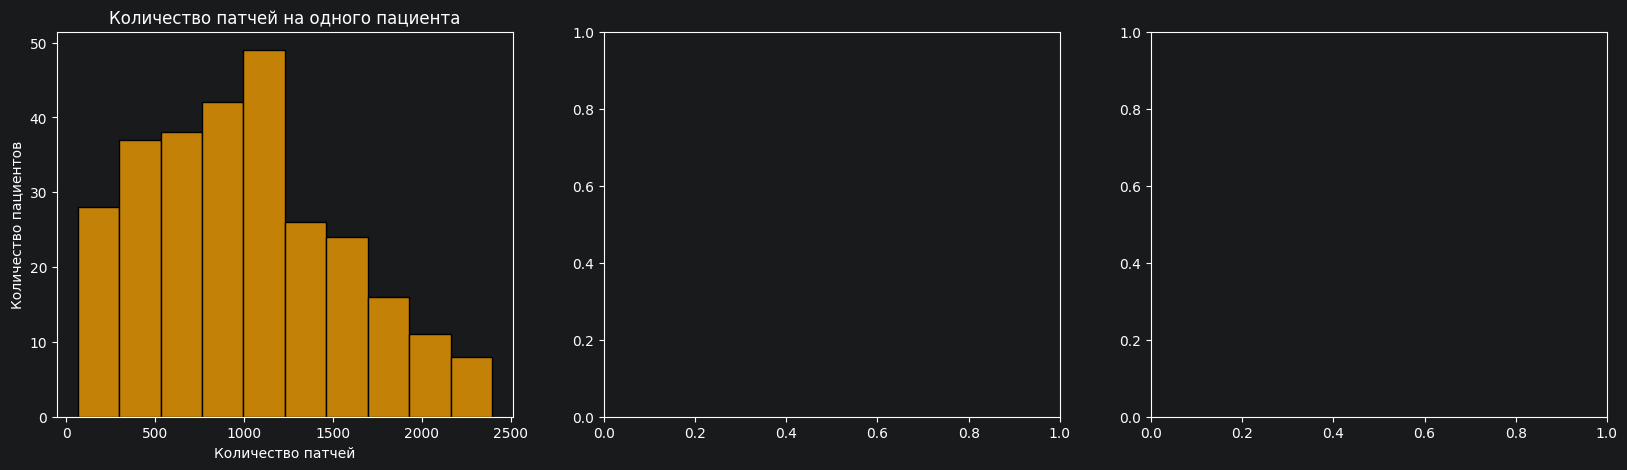

In [9]:
patient_target_counts = (
    data.groupby(["patient_id", "target"])
        .size()
        .unstack(fill_value=0)
)

fig, ax = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

patches_per_patient = patient_target_counts.sum(axis=1)
sns.histplot(
    patches_per_patient,
    ax=ax[0],
    color="orange"
)

ax[0].set_title("Количество патчей на одного пациента")
ax[0].set_xlabel("Количество патчей")
ax[0].set_ylabel("Количество пациентов")

ML

In [10]:
SEED = 42


In [11]:
np.random.seed(SEED)

In [12]:
data.target = data.target.astype(int)

In [13]:
patients = data.patient_id.unique()

sgkf_test = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

train_id, test_id = next(sgkf_test.split(X=data.path, y=data.target, groups=data.patient_id))

In [14]:
train_df = data.iloc[train_id].copy()
test_df = data.iloc[test_id].copy()

In [15]:
sgkf_val = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=SEED
)
train_id, val_id = next(sgkf_test.split(X=train_df.path, y=train_df.target, groups=train_df.patient_id))

In [16]:
train_df = data.iloc[train_id].copy()
val_df = data.iloc[val_id].copy()

In [17]:
train_df, _ = train_test_split(train_df, train_size=40000, stratify=train_df["target"], random_state=42)
val_df, _ = train_test_split(val_df, train_size=10000, stratify=val_df["target"], random_state=42)
test_df, _ = train_test_split(test_df, train_size=10000, stratify=test_df["target"], random_state=42)

In [18]:
OUTPUT_DIR = Path("./data/breast_cancer/splits/")
if OUTPUT_DIR.exists() and is_colab():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

splits = {
    "train": train_df,
    "val": val_df,
    "test": test_df,
}


def copy_dataframe_images(dataframe, split_name, output_dir):
    copied = 0

    for class_name in ("0", "1"):
        class_dir = output_dir / split_name / class_name
        class_dir.mkdir(parents=True, exist_ok=True)

    for row in tqdm(
        dataframe.itertuples(index=False),
        total=len(dataframe),
        desc=f"Копирование {split_name}"
    ):
        source_path = Path(row.path)
        target = str(int(row.target))


        destination_dir = output_dir / split_name / target
        destination_path = destination_dir / source_path.name

        shutil.copy2(source_path, destination_path)

        copied += 1

    print(
        f"{split_name}: скопировано {copied}"
    )


for split_name, dataframe in splits.items():
    copy_dataframe_images(
        dataframe=dataframe,
        split_name=split_name,
        output_dir=OUTPUT_DIR
    )

Копирование train: 100%|██████████| 40000/40000 [00:19<00:00, 2070.65it/s]


train: скопировано 40000


Копирование val: 100%|██████████| 10000/10000 [00:04<00:00, 2187.81it/s]


val: скопировано 10000


Копирование test: 100%|██████████| 10000/10000 [00:04<00:00, 2135.46it/s]


test: скопировано 10000


In [19]:
BATCH_SIZE = 32
IMG_SIZE = (96, 96)

In [20]:
train_ds  = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "train",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 40000 files belonging to 2 classes.


In [21]:
val_ds  = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "val",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

Found 10000 files belonging to 2 classes.


In [22]:
test_ds  = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "test",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

Found 10000 files belonging to 2 classes.


In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [24]:
from sklearn.utils import compute_class_weight

class_weights = compute_class_weight(y=train_df.target.values, class_weight="balanced", classes=train_df.target.unique())
class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

class_weights

{0: np.float64(0.7055918151349444), 1: np.float64(1.716001716001716)}

In [25]:
augmentation = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
])

In [26]:
def get_model_builder(base_model_function, preprocess_function=None):

    def build_model(hp):
        inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

        x = augmentation(inputs)

        if preprocess_function is not None:
            x = preprocess_function(x)

        base_model = base_model_function(
                include_top=False,
                weights="imagenet",
                input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        )

        base_model.trainable = False



        dense_units = hp.Choice("dense_units", values=[64, 128, 256])
        dropout = hp.Float("dropout", min_value=0.2, max_value=0.5, step=0.1)
        learning_rate = hp.Choice("learning_rate", values=[1e-3, 3e-4, 1e-4])

        x = base_model(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(dense_units, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
        outputs = layers.Dense(1, activation="sigmoid")(x)

        model = keras.Model(inputs, outputs)

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss="binary_crossentropy",
            metrics=[keras.metrics.AUC(name="pr_auc", curve="PR")],
        )
        return model

    return build_model

In [27]:
def tune_model(base_model_function, preprocess_function, model_name):
    wandb_run = wandb.init(
        project=WANDB_PROJECT,
        name=model_name,
        config={
            "model_name": model_name,
            "batch_size": BATCH_SIZE,
            "img_size": IMG_SIZE,
            "max_trials": 3,
            "tuner": "RandomSearch"
        }
    )

    model_builder = get_model_builder(base_model_function, preprocess_function)

    tuner = keras_tuner.RandomSearch(
        model_builder,
        objective=keras_tuner.Objective("val_pr_auc", direction="max"),
        max_trials=3,
        executions_per_trial=2,
        directory="./tuner_results",
        project_name=model_name,
        overwrite=True
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=2,
        restore_best_weights=True
    )

    wandb_callback = WandbMetricsLogger(log_freq="batch")

    tuner.search(
        train_ds,
        validation_data=val_ds,
        epochs=2,
        class_weight=class_weights,
        callbacks=[early_stopping, wandb_callback]
    )

    best_parameters = tuner.get_best_hyperparameters(1)[0]

    print("Лучшие параметры:")
    print("Dense:", best_parameters.get("dense_units"))
    print("Dropout:", best_parameters.get("dropout"))
    print("Learning rate:", best_parameters.get("learning_rate"))

    wandb.config.update({
        "best_dense_units": best_parameters.get("dense_units"),
        "best_dropout": best_parameters.get("dropout"),
        "best_learning_rate": best_parameters.get("learning_rate")
    }, allow_val_change=True)

    best_trial = tuner.oracle.get_best_trials(1)[0]
    if best_trial.score is not None:
        wandb.log({"best_val_pr_auc": best_trial.score})

    best_model = tuner.get_best_models(num_models=1)[0]

    model_dir = Path("./models")
    model_dir.mkdir(exist_ok=True)
    model_path = model_dir / f"{model_name}_best.keras"
    best_model.save(model_path)

    artifact = wandb.Artifact(f"{model_name}_best_model", type="model")
    artifact.add_file(str(model_path))
    wandb.log_artifact(artifact)

    wandb_run.finish()

    return best_model, best_parameters, tuner

In [28]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [29]:
resnet_model, resnet_parameters, resnet_tuner = tune_model(
    keras.applications.ResNet50V2,
    keras.applications.resnet_v2.preprocess_input,
    "resnet50v2"
)

Trial 3 Complete [00h 11m 45s]
val_pr_auc: 0.8107460141181946

Best val_pr_auc So Far: 0.8117451369762421
Total elapsed time: 00h 31m 35s
Лучшие параметры:
Dense: 256
Dropout: 0.4
Learning rate: 0.001


C:\Users\vokhm\miniconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


best_val_pr_auc,▁
epoch/epoch,▁█▁█▁█▁█▁█▁█
epoch/learning_rate,████▁▁▁▁▁▁▁▁
epoch/loss,█▂█▂▇▁█▁█▁█▁
epoch/pr_auc,▂▇▁█▂█▁█▁▇▁▇
epoch/val_loss,█▁▃▁▄▁▃▁▅▃▃▄
epoch/val_pr_auc,▂█▄▇▁▇▂▇▃█▁▆
best_val_pr_auc,0.81175
epoch/epoch,1
epoch/learning_rate,0.0003
epoch/loss,0.42731


In [30]:
mobilenet_model, mobilenet_parameters, mobilenet_tuner = tune_model(
    keras.applications.MobileNetV2,
    keras.applications.mobilenet_v2.preprocess_input,
    "mobilenetv2"
)

Trial 3 Complete [00h 03m 31s]
val_pr_auc: 0.846868097782135

Best val_pr_auc So Far: 0.846868097782135
Total elapsed time: 00h 10m 42s
Лучшие параметры:
Dense: 64
Dropout: 0.2
Learning rate: 0.001


C:\Users\vokhm\miniconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


best_val_pr_auc,▁
epoch/epoch,▁█▁█▁█▁█▁█▁█
epoch/learning_rate,▁▁▁▁▃▃▃▃████
epoch/loss,▇▂▇▂▇▃█▃▆▂▅▁
epoch/pr_auc,▂▇▂▇▂▆▁▆▄█▄█
epoch/val_loss,█▃█▅▅▃▅▅▃▃▃▁
epoch/val_pr_auc,▁▄▁▃▂▅▃▅▅▅▅█
best_val_pr_auc,0.84687
epoch/epoch,1
epoch/learning_rate,0.001
epoch/loss,0.37178


In [32]:
efficientnet_model, efficientnet_parameters, efficientnet_tuner = tune_model(
    keras.applications.EfficientNetV2B0,
    keras.applications.efficientnet.preprocess_input,
    "efficientnetb0"
)

Trial 3 Complete [00h 04m 59s]
val_pr_auc: 0.8337100446224213

Best val_pr_auc So Far: 0.8349734246730804
Total elapsed time: 00h 14m 12s
Лучшие параметры:
Dense: 64
Dropout: 0.30000000000000004
Learning rate: 0.001


C:\Users\vokhm\miniconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


best_val_pr_auc,▁
epoch/epoch,▁█▁█▁█▁█▁█▁█
epoch/learning_rate,████████▁▁▁▁
epoch/loss,▆▁▆▂▆▂▆▁█▂█▂
epoch/pr_auc,▃█▃▇▂▇▃█▁▇▁▇
epoch/val_loss,▇▁▃▃█▁▂▂▄▂▅▂
epoch/val_pr_auc,▃▇▇█▃▆▂▅▁▇▂▆
best_val_pr_auc,0.83497
epoch/epoch,1
epoch/learning_rate,0.0003
epoch/loss,0.41846
